# Лабораторная работа 2. Numpy, Pandas, графики.

<font color='red'> Важно! </font> Здесь и далее от вас просится корректное использование type hints в функциях, классах, методах и.т.д.


## 1. О джунглях и матицах (1.5 балла)

### 1.1 Создание матриц (0.25 балла)

Создайте 4 матрицы
- A - "шахматную" из нулей и единиц, размера 6 на 3, левое верхнее значение (A[0][0]) равно 1,
- В - из чисел от 1 до 24, записанных в виде змейки, размера 6 на 4,
- C - из случайных целых чисел от 2 до 10 (обе границы включительно), размера 4 на 3
- D - из нулей с единичками на главной диагонали, размера 4 на 4.

**Создайте из этих матриц "лоскутную" матрицу S**

A В

С D

используя **только стандартные** операции numpy. Comprehensions использовать нельзя.

После этого допишите к полученной матрице S матрицу F размера 10 на 2 из нулей, чтобы получилась матрица G:

S F

P.S. Когда мы говорим, что матрица имеет размер x на y, x - количество строк, y - количество столбцов.

In [115]:
import numpy as np

rows = np.arange(6).reshape(6, 1)
cols = np.arange(3)
A = ((rows + cols) % 2 == 0).astype(int)

B = np.arange(1, 25).reshape(6, 4)
B[1::2] = B[1::2, ::-1]

np.random.seed(42)
C = np.random.randint(2, 11, (4, 3))

D = np.eye(4, dtype=int)

S = np.vstack((np.hstack((A, B)), np.hstack((C, D))))

F = np.zeros((10, 2), dtype=int)

G = np.hstack((S, F))

print(A)
print(B)
print(C)
print(D)
print(S)
print(F)
print(G)

[[1 0 1]
 [0 1 0]
 [1 0 1]
 [0 1 0]
 [1 0 1]
 [0 1 0]]
[[ 1  2  3  4]
 [ 8  7  6  5]
 [ 9 10 11 12]
 [16 15 14 13]
 [17 18 19 20]
 [24 23 22 21]]
[[8 5 9]
 [6 8 4]
 [8 9 6]
 [5 9 9]]
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
[[ 1  0  1  1  2  3  4]
 [ 0  1  0  8  7  6  5]
 [ 1  0  1  9 10 11 12]
 [ 0  1  0 16 15 14 13]
 [ 1  0  1 17 18 19 20]
 [ 0  1  0 24 23 22 21]
 [ 8  5  9  1  0  0  0]
 [ 6  8  4  0  1  0  0]
 [ 8  9  6  0  0  1  0]
 [ 5  9  9  0  0  0  1]]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]
[[ 1  0  1  1  2  3  4  0  0]
 [ 0  1  0  8  7  6  5  0  0]
 [ 1  0  1  9 10 11 12  0  0]
 [ 0  1  0 16 15 14 13  0  0]
 [ 1  0  1 17 18 19 20  0  0]
 [ 0  1  0 24 23 22 21  0  0]
 [ 8  5  9  1  0  0  0  0  0]
 [ 6  8  4  0  1  0  0  0  0]
 [ 8  9  6  0  0  1  0  0  0]
 [ 5  9  9  0  0  0  1  0  0]]


### 1.2 Джунгли зовут! (0.25 балла)

Перед вами матрица M - карта местности тяжелопроходимых джунглей, составленная Ларой Крофт. На карте каждая ячейка - целое число, обозначающее высоту над уровнем моря (если число больше нуля) в метрах или глубину моря (если число меньше нуля) в метрах в данной ячейке карты размером метр на метр. Если число 0, то это часть суши - берег.


Вам необходимо посчитать:
- Общую площадь клеточек моря, в которых его глубина больше 5 (в м^2)
- Общий объём всей воды на карте (в м^3)
- Максимальную высоту над уровнем моря, которая есть на этой карте (в м)

In [3]:
import numpy as np

def find_deep_sea_area(M: np.array) -> int:
    return int(np.sum(M < -5))

def find_water_volume(M: np.array) -> int:
    return -np.sum(M[np.where(M < 0)])

def find_max_height(M: np.array) -> int:
    return M[np.where(M > 0)].max()

In [4]:
# Можно подставить свой пример
M = np.array([
    [-7, -3, -1, 0],
    [-4, -3, 1, 19],
    [-2, 0, 4, 25],
    [-1, 3, 6, 9]
])

# простая проверка для примера выше
assert np.isclose(find_deep_sea_area(M), 1)
assert np.isclose(find_water_volume(M), 21)
assert np.isclose(find_max_height(M), 25)

print("Общая площадь моря глубиной более 5м на карте -", find_deep_sea_area(M), "м^2")
print("Общий объем воды на карте -", find_water_volume(M), "м^3")
print("Максимальный уровень над уровнем моря на карте -", find_max_height(M), "м")

Общая площадь моря глубиной более 5м на карте - 1 м^2
Общий объем воды на карте - 21 м^3
Максимальный уровень над уровнем моря на карте - 25 м


### 1.3 Функция проверки (0.5 балла)

На вход функции поступает произвольное (>2) кортежей размеров (shape) различных матриц. Необходимо вернуть True если можно последовательно сложить эти матрицы (возможно, с помощью broadcasting), и False если нет.

In [5]:
def check_successful_broadcast(*matrices) -> bool:
    max_ndim = max(len(shape) for shape in matrices)

    new = []
    for shape in matrices:
        new.append((1,) * (max_ndim - len(shape)) + shape)

    for dim in range(max_ndim):
        dim_values = [space[dim] for space in new]

        max_value = max(dim_values)

        for value in dim_values:
            if value != 1 and value != max_value:
                return False

    return True

In [6]:
assert check_successful_broadcast((5, 6, 7), (6, 7), (1, 7))
assert check_successful_broadcast((30358, 49348, 238, 239), (1, 239), (239,))
assert check_successful_broadcast((2498293529, 23524600), (239725453, 230523058, 2398620), (932759034, 3502, 532, 436, 34, 436))


<class 'AssertionError'>: 

### 1.4 Попарные расстояния (0.5 балла)

На вход подаются матрицы A размера m x k и матрица B размера n x k. Нужно получить матрицу размера m x n, содержащую попарные евклидовы расстояния.

Можно пользоваться только базовыми функциями, нельзя пользоваться циклами, сторонними библиотеками; скорее всего, пригодится broadcasting. Авторское решение записывается **в одну строчку** в соответствии со всеми правилами кодстайла.

In [7]:
import numpy as np

def pairwise_distances(A, B):
    return np.sqrt(((A[:, None, :] - B) ** 2).sum(axis=2))

In [8]:
A = np.array([[1, 2, 3],
     [4, 5, 6]])
B = np.array([[7, 8, 9],
     [10, 11, 12],
     [13, 14, 15]])

pairwise_distances(A, B)

array([[10.39230485, 15.58845727, 20.78460969],
       [ 5.19615242, 10.39230485, 15.58845727]])

Объясни принцип работы этой одной строчки. Что именно происходит в ней?

<b><font color="#FF69B4"> Ваш ответ здесь </font></b>

A[:, None, :] - расширяет матрицу из (m, k) в (m, 1, k)

(A[:, None, :] - B) ** 2 - broadcasting + возведение поэлементно в квадрат

.sum(axis=2) - складывает по последней оси

np.sqrt() - извлекает квадратный корень с каждого элемента

## 2. О реализации своего NumPy (4 балла)

### 2.1 my_transpose (0.5 балла)

Напиши свою функцию `my_transpose`, которая принимает на вход 2D матрицу и транспонирует её. Пользоваться готовыми функциями/методами из NumPy НЕЛЬЗЯ.

In [9]:
def my_transpose(matrix: np.array) -> np.array:
    rows, cols = matrix.shape

    result = np.empty((cols, rows), dtype=matrix.dtype)
    for i in range(cols):
        for j in range(rows):
            result[i, j] = matrix[j, i]

    return result

In [10]:
matrix = np.array([[0, 0, 1],
                   [0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 2]])

print(my_transpose(matrix))

[[0 0 1 0]
 [0 1 0 0]
 [1 0 0 2]]


### 2.2 my_determinant (0.5 балла)

Напиши свою функцию `my_determinant`, которая принимает на вход 2D матрицу размера n x n и считает её определитель. Пользоваться готовыми функциями/методами из NumPy НЕЛЬЗЯ.

In [11]:
def my_determinant(matrix: np.array) -> float:
    n = matrix.shape[0]

    if n == 1:
        return float(matrix[0, 0])
    if n == 2:
        return float(matrix[0, 0] * matrix[1, 1] - matrix[0, 1] * matrix[1, 0])

    det = 0.0
    for i in range(n):
        sign = (-1) ** i
        minor = np.delete(np.delete(matrix, i, axis=0), 0, axis=1)
        det += sign * matrix[i, 0] * my_determinant(minor)

    return det

In [12]:
matrix = np.array([[3.141592, 2.71828, 1.618],
                   [0, 0, 1],
                   [2834623, 32524, 233]])

print(my_determinant(matrix))

7603121.870232


### 2.3 my_multiplication (0.75 балла)

Напиши свою функцию `my_multiplication`, которая принимает на вход 2 2D матрицы и считает их произведение. Если матрицы нельзя перемножить, то надо поднять `MultiplicationError`. Пользоваться готовыми функциями/методами НЕЛЬЗЯ.

In [13]:
class MultiplicationError(Exception):
    pass

def my_multiplication(matrix_a: np.array, matrix_b:np.array) -> np.array:
    rows_a, cols_a = matrix_a.shape
    rows_b, cols_b = matrix_b.shape

    if cols_a != rows_b:
        raise MultiplicationError("Невозможно перемножить матрицы")

    result = np.zeros((rows_a, cols_b), dtype=float)

    for i in range(rows_a):
        for j in range(cols_b):
            aij = 0
            for k in range(cols_a):
                aij += matrix_a[i, k] * matrix_b[k, j]
            result[i, j] += aij

    return result

In [14]:
A = np.array([[1, 2],
              [3, 4]], dtype=float)
B = np.array([[5, 6],
              [7, 8]], dtype=float)

print(my_multiplication(A, B))

A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)
B = np.array([[7, 8],
              [9, 10],
              [11, 12]], dtype=float)

print(my_multiplication(A, B))

A = np.array([[1, 2]], dtype=float)
B = np.array([[3, 4, 5]], dtype=float)
print(my_multiplication(A, B))

[[19. 22.]
 [43. 50.]]
[[ 58.  64.]
 [139. 154.]]


<class '__main__.MultiplicationError'>: Невозможно перемножить матрицы

### 2.4 my_inverse (0.75 балла)

Напиши свою функцию `my_inverse`, которая принимает на вход 2D матрицу и считает обратную к ней. Если у матрицы нет обратной, то надо поднять `InversionError`. Пользоваться готовыми функциями/методами НЕЛЬЗЯ.

In [15]:
class InversionError(Exception):
    pass

def my_inverse(matrix: np.array) -> np.array:
    n = matrix.shape[0]
    if matrix.shape[1] != n:
        raise InversionError("Матрица должна быть квадратной")
    
    aug = np.zeros((n, 2*n), dtype=float)
    for i in range(n):
        for j in range(n):
            aug[i, j] = matrix[i, j]
        aug[i, n + i] = 1.0
    
    for i in range(n):
        pivot_row = i
        for r in range(i + 1, n):
            if abs(aug[r, i]) > abs(aug[pivot_row, i]):
                pivot_row = r
        
        if abs(aug[pivot_row, i]) < 1e-10:
            raise InversionError("Матрица вырожденная")
        
        if pivot_row != i:
            aug[[i, pivot_row]] = aug[[pivot_row, i]]
        
        pivot = aug[i, i]
        for j in range(2*n):
            aug[i, j] /= pivot
        
        for r in range(i + 1, n):
            factor = aug[r, i]
            for j in range(2*n):
                aug[r, j] -= factor * aug[i, j]
    
    for i in range(n - 1, -1, -1):
        for r in range(i - 1, -1, -1):
            factor = aug[r, i]
            for j in range(2*n):
                aug[r, j] -= factor * aug[i, j]
    
    inverse = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            inverse[i, j] = aug[i, n + j]
    
    return inverse

In [16]:
A = np.array([[4, 7],
              [2, 6]], dtype=float)
A_inv = my_inverse(A)
print(A_inv)
print(np.dot(A, A_inv))

B = np.array([[2, 1, 1],
              [1, 2, 1],
              [1, 1, 2]], dtype=float)
B_inv = my_inverse(B)
print(B_inv)
print(np.dot(B, B_inv))

C = np.array([[1, 2],
              [2, 4]], dtype=float)
print(my_inverse(C))

[[ 0.6 -0.7]
 [-0.2  0.4]]
[[1. 0.]
 [0. 1.]]
[[ 0.75 -0.25 -0.25]
 [-0.25  0.75 -0.25]
 [-0.25 -0.25  0.75]]
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-1.11022302e-16  0.00000000e+00  1.00000000e+00]]


<class '__main__.InversionError'>: Матрица вырожденная

### 2.5 my_lsq (0.75 балла)

Напиши свою функцию `my_lsq`, которая принимает на вход 2D матрицу A и матрицу b, а возвращает решение методом наименьших квадратов. Если не совпадают размерности, то надо поднять `LeastSquaresError`. Пользоваться готовыми функциями/методами НЕЛЬЗЯ.

In [17]:
class LeastSquaresError:
    pass

def my_lsq(A: np.array, b: np.array) -> np.array:
    if b.ndim == 1:
        b = b.reshape(-1, 1)

    m, n = A.shape
    mb, kb = b.shape

    if m != mb:
        raise LeastSquaresError(f"Число строк A ({m}) не равно числу строк b ({mb})")
    if kb != 1:
        raise LeastSquaresError(f"b должна быть вектором-столбцом")

    At = my_transpose(A)
    AtA = my_multiplication(At, A)
    Atb = my_multiplication(At, b)
    return my_multiplication(my_inverse(AtA), Atb)

In [18]:
A = np.array([[1, 0],
              [1, 1],
              [1, 2],
              [1, 3]])

b = np.array([[1],
              [2],
              [3],
              [5]])

result = my_lsq(A, b)
print(f"a = {result[0, 0]}, b = {result[1, 0]}")

a = 0.7999999999999998, b = 1.2999999999999994


### 2.6 Замеры времени (0.75 балла)

Напиши функцию `benchmark`, которая принимает на вход функцию и произвольное число аргументов, она замеряет время выполнения через `time.time()` и выводит информацию о том, за сколько эта функция отработала.


Возьмите примеры из 2.1 - 2.6, запустите их на трёх вариантах:

- на `list`
- на `np.array()`

Также запусти соответствующие функций/методов из обычного Numpy

In [19]:
import time
import random

class MultiplicationError(Exception):
    pass

class InversionError(Exception):
    pass

class LeastSquaresError(Exception):
    pass

def my_transpose(matrix):
    if isinstance(matrix, np.ndarray):
        rows, cols = matrix.shape
        result = np.empty((cols, rows), dtype=matrix.dtype)
        for i in range(rows):
            for j in range(cols):
                result[j, i] = matrix[i, j]
        return result
    else:
        rows = len(matrix)
        cols = len(matrix[0])
        result = [[0 for _ in range(rows)] for _ in range(cols)]
        for i in range(rows):
            for j in range(cols):
                result[j][i] = matrix[i][j]
        return result

def my_determinant(matrix):
    if isinstance(matrix, np.ndarray):
        mat = matrix.tolist()
    else:
        mat = matrix
    
    n = len(mat)
    
    if n == 1:
        return mat[0][0]
    if n == 2:
        return mat[0][0] * mat[1][1] - mat[0][1] * mat[1][0]
    
    det = 0
    for j in range(n):
        sign = (-1) ** j
        minor = [row[:j] + row[j+1:] for row in mat[1:]]
        det += sign * mat[0][j] * my_determinant(minor)
    return det

def my_multiplication(matrix_a, matrix_b):
    if isinstance(matrix_a, np.ndarray) and isinstance(matrix_b, np.ndarray):
        rows_a, cols_a = matrix_a.shape
        rows_b, cols_b = matrix_b.shape
    else:
        rows_a = len(matrix_a)
        cols_a = len(matrix_a[0])
        rows_b = len(matrix_b)
        cols_b = len(matrix_b[0])
    
    if cols_a != rows_b:
        raise MultiplicationError
    
    if isinstance(matrix_a, np.ndarray) and isinstance(matrix_b, np.ndarray):
        result = np.zeros((rows_a, cols_b), dtype=float)
        for i in range(rows_a):
            for j in range(cols_b):
                total = 0.0
                for k in range(cols_a):
                    total += matrix_a[i, k] * matrix_b[k, j]
                result[i, j] = total
        return result
    else:
        result = [[0 for _ in range(cols_b)] for _ in range(rows_a)]
        for i in range(rows_a):
            for j in range(cols_b):
                total = 0
                for k in range(cols_a):
                    total += matrix_a[i][k] * matrix_b[k][j]
                result[i][j] = total
        return result

def my_inverse(matrix):
    if isinstance(matrix, np.ndarray):
        n = matrix.shape[0]
        if matrix.shape[1] != n:
            raise InversionError
        aug = np.zeros((n, 2*n), dtype=float)
        for i in range(n):
            for j in range(n):
                aug[i, j] = matrix[i, j]
            aug[i, n + i] = 1.0
    else:
        n = len(matrix)
        aug = [row[:] + [0]*i + [1] + [0]*(n-i-1) for i, row in enumerate(matrix)]
    
    for i in range(n):
        if isinstance(matrix, np.ndarray):
            pivot_row = i
            for r in range(i + 1, n):
                if abs(aug[r, i]) > abs(aug[pivot_row, i]):
                    pivot_row = r
            if abs(aug[pivot_row, i]) < 1e-10:
                raise InversionError
            if pivot_row != i:
                aug[[i, pivot_row]] = aug[[pivot_row, i]]
            pivot = aug[i, i]
            for j in range(2*n):
                aug[i, j] /= pivot
            for r in range(i + 1, n):
                factor = aug[r, i]
                for j in range(2*n):
                    aug[r, j] -= factor * aug[i, j]
        else:
            pivot = i
            for r in range(i+1, n):
                if abs(aug[r][i]) > abs(aug[pivot][i]):
                    pivot = r
            if abs(aug[pivot][i]) < 1e-10:
                raise InversionError
            aug[i], aug[pivot] = aug[pivot], aug[i]
            pivot_val = aug[i][i]
            for j in range(2*n):
                aug[i][j] /= pivot_val
            for r in range(n):
                if r != i:
                    factor = aug[r][i]
                    for j in range(2*n):
                        aug[r][j] -= factor * aug[i][j]
    
    if isinstance(matrix, np.ndarray):
        for i in range(n - 1, -1, -1):
            for r in range(i - 1, -1, -1):
                factor = aug[r, i]
                for j in range(2*n):
                    aug[r, j] -= factor * aug[i, j]
        inverse = np.zeros((n, n), dtype=float)
        for i in range(n):
            for j in range(n):
                inverse[i, j] = aug[i, n + j]
        return inverse
    else:
        inverse = [row[n:] for row in aug]
        return inverse

def my_lsq(A, b):
    if isinstance(A, np.ndarray):
        if b.ndim == 1:
            b = b.reshape(-1, 1)
        m, n = A.shape
        mb, kb = b.shape
        if m != mb:
            raise LeastSquaresError
        if kb != 1:
            raise LeastSquaresError
        
        At = np.zeros((n, m), dtype=float)
        for i in range(m):
            for j in range(n):
                At[j, i] = A[i, j]
        
        AtA = np.zeros((n, n), dtype=float)
        for i in range(n):
            for j in range(n):
                total = 0.0
                for k in range(m):
                    total += At[i, k] * A[k, j]
                AtA[i, j] = total
        
        Atb = np.zeros((n, 1), dtype=float)
        for i in range(n):
            total = 0.0
            for k in range(m):
                total += At[i, k] * b[k, 0]
            Atb[i, 0] = total
        
        aug = np.zeros((n, n + 1), dtype=float)
        for i in range(n):
            for j in range(n):
                aug[i, j] = AtA[i, j]
            aug[i, n] = Atb[i, 0]
        
        for i in range(n):
            pivot_row = i
            for r in range(i + 1, n):
                if abs(aug[r, i]) > abs(aug[pivot_row, i]):
                    pivot_row = r
            if abs(aug[pivot_row, i]) < 1e-10:
                raise LeastSquaresError
            if pivot_row != i:
                aug[[i, pivot_row]] = aug[[pivot_row, i]]
            pivot = aug[i, i]
            for j in range(n + 1):
                aug[i, j] /= pivot
            for r in range(i + 1, n):
                factor = aug[r, i]
                for j in range(n + 1):
                    aug[r, j] -= factor * aug[i, j]
        
        x = np.zeros((n, 1), dtype=float)
        for i in range(n - 1, -1, -1):
            x[i, 0] = aug[i, n]
            for j in range(i + 1, n):
                x[i, 0] -= aug[i, j] * x[j, 0]
        return x
    else:
        m = len(A)
        n = len(A[0])
        if len(b) != m:
            raise LeastSquaresError
        
        At = [[A[j][i] for j in range(m)] for i in range(n)]
        
        AtA = [[0 for _ in range(n)] for _ in range(n)]
        for i in range(n):
            for j in range(n):
                total = 0
                for k in range(m):
                    total += At[i][k] * A[k][j]
                AtA[i][j] = total
        
        Atb = [[0] for _ in range(n)]
        for i in range(n):
            total = 0
            for k in range(m):
                total += At[i][k] * b[k][0]
            Atb[i][0] = total
        
        aug = [AtA[i] + [Atb[i][0]] for i in range(n)]
        
        for i in range(n):
            pivot = i
            for r in range(i+1, n):
                if abs(aug[r][i]) > abs(aug[pivot][i]):
                    pivot = r
            if abs(aug[pivot][i]) < 1e-10:
                raise LeastSquaresError
            aug[i], aug[pivot] = aug[pivot], aug[i]
            pivot_val = aug[i][i]
            for j in range(i, n+1):
                aug[i][j] /= pivot_val
            for r in range(i+1, n):
                factor = aug[r][i]
                for j in range(i, n+1):
                    aug[r][j] -= factor * aug[i][j]
        
        x = [[0] for _ in range(n)]
        for i in range(n-1, -1, -1):
            x[i][0] = aug[i][n]
            for j in range(i+1, n):
                x[i][0] -= aug[i][j] * x[j][0]
        return x

def benchmark(func, *args):
    start = time.time()
    result = func(*args)
    end = time.time()
    print(f"{func.__name__}: {end - start:.6f} сек")
    return result

In [20]:
print("=" * 60)
print("БЕНЧМАРКИНГ")
print("=" * 60)

sizes = [10, 30, 50]

for size in sizes:
    print(f"\n--- РАЗМЕР {size}x{size} ---")
    
    A_list = [[random.random() for _ in range(size)] for _ in range(size)]
    B_list = [[random.random() for _ in range(size)] for _ in range(size)]
    b_list = [[random.random()] for _ in range(size)]
    
    A_np = np.array(A_list)
    B_np = np.array(B_list)
    b_np = np.array(b_list)
    
    print("\n2.1 Транспонирование:")
    if size <= 50:
        benchmark(my_transpose, A_list)
    benchmark(my_transpose, A_np)
    benchmark(np.transpose, A_np)
    
    print("\n2.2 Определитель (size <= 10):")
    if size <= 10:
        benchmark(my_determinant, A_list)
        benchmark(my_determinant, A_np)
        benchmark(np.linalg.det, A_np)
    
    print("\n2.3 Умножение:")
    if size <= 50:
        benchmark(my_multiplication, A_list, B_list)
    benchmark(my_multiplication, A_np, B_np)
    benchmark(np.dot, A_np, B_np)
    
    print("\n2.4 Обратная матрица (size <= 30):")
    if size <= 30:
        if size <= 15:
            benchmark(my_inverse, A_list)
        benchmark(my_inverse, A_np)
        benchmark(np.linalg.inv, A_np)
    
    print("\n2.5 МНК:")
    if size <= 30:
        m = size
        n = size // 2
        A_list_lsq = [[random.random() for _ in range(n)] for _ in range(m)]
        b_list_lsq = [[random.random()] for _ in range(m)]
        A_np_lsq = np.array(A_list_lsq)
        b_np_lsq = np.array(b_list_lsq)
        
        benchmark(my_lsq, A_list_lsq, b_list_lsq)
        benchmark(my_lsq, A_np_lsq, b_np_lsq)
        benchmark(np.linalg.lstsq, A_np_lsq, b_np_lsq)

print("\n" + "=" * 60)
print("АНАЛИЗ")
print("=" * 60)

БЕНЧМАРКИНГ

--- РАЗМЕР 10x10 ---

2.1 Транспонирование:
my_transpose: 0.001000 сек
my_transpose: 0.000000 сек
transpose: 0.000000 сек

2.2 Определитель (size <= 10):
my_determinant: 13.493000 сек
my_determinant: 14.243000 сек
det: 0.000000 сек

2.3 Умножение:
my_multiplication: 0.001000 сек
my_multiplication: 0.002000 сек
dot: 0.000000 сек

2.4 Обратная матрица (size <= 30):
my_inverse: 0.001000 сек
my_inverse: 0.006000 сек
inv: 0.000000 сек

2.5 МНК:
my_lsq: 0.000000 сек
my_lsq: 0.002000 сек
lstsq: 0.000000 сек

--- РАЗМЕР 30x30 ---

2.1 Транспонирование:
my_transpose: 0.001000 сек
my_transpose: 0.001000 сек
transpose: 0.000000 сек

2.2 Определитель (size <= 10):

2.3 Умножение:
my_multiplication: 0.010000 сек
my_multiplication: 0.059000 сек
dot: 0.000000 сек

2.4 Обратная матрица (size <= 30):
my_inverse: 0.135000 сек
inv: 0.000000 сек

2.5 МНК:
my_lsq: 0.003000 сек
my_lsq: 0.019000 сек
lstsq: 0.001000 сек

--- РАЗМЕР 50x50 ---

2.1 Транспонирование:
my_transpose: 0.001000 сек
my_tr

Проанализируй результаты замеров. Почему так вышло?


<b><font color="#FF69B4"> Ваш ответ здесь </font></b>

np.array быстрее list, т.к. np.array написан на С.
встроенные функции быстрее, т.к. они оптимизированны.

# 3. О накручивании себя и чёрном саморезе (2 балла)

А сейчас, дамы и господа, мы научимся использовать библиотеки для анализа данных в реальности!

**Причина появления этого раздела проста**: многие студенты ПМФ даже во втором и третьем семестрах продолжают использовать Excel, калькулятор или лист бумаги. Хочется открыть глаза на ещё один способ выполнения лабораторных с намного меньшим порогом вхождения, чем тот же Excel. Авторы надеются, что кого-то это замотивирует присмотреться к удобным библиотекам.

*Спонсор данных для раздела - blacksamorez. Без него пять счастливых семестров лаб были бы совсем не счастливыми...*

In [21]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.376 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##  3.1. Постановка задачи и данные

Предположим, у нас есть гироскоп с прицепленным к его оси грузом на рычаге (см. рисунок для быстрого понимания, а подробности можно узнать в [лабораторном практикуме](https://lib.mipt.ru/book/267519/), том 1, стр.160). Из-за наличия груза гироскоп начинает медленно [прецессировать](https://ru.wikipedia.org/wiki/%D0%9F%D1%80%D0%B5%D1%86%D0%B5%D1%81%D1%81%D0%B8%D1%8F), т.е. вращаться вокруг вертикальной оси с какой-то более-менее постоянной частотой.

Мы с вами разберём часть этой лабораторной, в основном касающуюся обработки данных и построения графиков.

<center><img src='https://drive.google.com/uc?export=view&id=1KfYQ0hKYRDhi5uk7C8lNffZBNy8NF7nu' width=600>

Изображение гироскопа с подвешенным грузом Г и рычагом С</center>

Для начала посмотрим на данные, которые любезно кто-то для нас собрал. Создайте датафрейм из [файла](https://drive.google.com/file/d/1SbLR6R16obqLewUTnX1CAAjQTrVXh2Vq/view?usp=sharing)

In [34]:
data = pd.DataFrame({
    'N': [4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 6, 6, 6, 6, 6, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5],
    't_sec': [268, 264, 275, 263, 267, 235, 226, 234, 229, 230, 203, 207, 199, 205, 204, 287, 278, 282, 282, 285, 175, 175, 178, 173, 176, 208, 210, 207, 209, 208],
    'sigma_t_sec': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'mass_gramm': [180, 180, 180, 180, 180, 216, 216, 216, 216, 216, 614, 614, 614, 614, 614, 142, 142, 142, 142, 142, 273, 273, 273, 273, 273, 341, 341, 341, 341, 341],
    'length_cm': [121, 121, 121, 121, 121, 108, 108, 108, 108, 108, 111, 111, 111, 111, 111, 121, 121, 121, 121, 121, 122, 122, 122, 122, 122, 110, 110, 110, 110, 110],
    'phi_rad': [0.16, 0.18, 0.16, 0.17, 0.17, 0.17, 0.15, 0.16, 0.16, 0.18, 0.16, 0.17, 0.17, 0.17, 0.16, 0.17, 0.16, 0.15, 0.17, 0.14, 0.16, 0.17, 0.16, 0.17, 0.17, 0.16, 0.16, 0.17, 0.17, 0.17]
})

data.head()

,N,t_sec,sigma_t_sec,mass_gramm,length_cm,phi_rad
0,4,268,1,180,121,0.16
1,4,264,1,180,121,0.18
2,4,275,1,180,121,0.16
3,4,263,1,180,121,0.17
4,4,267,1,180,121,0.17


## 3.2 Работа с данными (1 балл)

Колонки в датафрейме следующие:

N - количество полных оборотов гироскопа в эксперименте;

t, в секундах - время эксперимента;

$\sigma_t$ - погрешность измерения времени;

mass - масса груза, подвешенного к рычагу на гироскопе;

length - длина плеча вышеупомянутого рычага;

phi - угол в радианах, на который опустился рычаг за время эксперимента. Понадобится, чтобы оценить влияние силы трения в гироскопе на прецессию.

Так как физики любят оперировать величинами адекватной размерности, нужно перевести колонки с массой в килограммы, а с длиной - в метры. Затем переименуйте все колонки так, чтобы в них не осталось упоминаний о размерности - только названия физических величин.

In [35]:
data['mass'] = data['mass_gramm'] / 1000
data['length'] = data['length_cm'] / 100

assert data.mass.mean() < 0.3
assert np.allclose(data.length.mean(), 1.155)
assert all(' ' not in column for column in data.columns)

data.head()

,N,t_sec,sigma_t_sec,mass_gramm,length_cm,phi_rad,mass,length
0,4,268,1,180,121,0.16,0.18,1.21
1,4,264,1,180,121,0.18,0.18,1.21
2,4,275,1,180,121,0.16,0.18,1.21
3,4,263,1,180,121,0.17,0.18,1.21
4,4,267,1,180,121,0.17,0.18,1.21


Добавьте в датафрейм колонки с соответствующими именами и значениями, вычисленными по формулам:

`omega`: $\Omega = 2 \pi \cdot \frac{N}{t}$

`sigma_omega`: $\sigma_{\Omega} = \Omega / t \cdot \sigma_t$

`omega_down`: $\Omega_{down} = \varphi / t$

`sigma_down`: $\sigma_{down} =\Omega_{down} \cdot \sigma_t / t$

`momentum`: $M = m \cdot g \cdot l$ (`g = 9.8 м/с^2`)

`momentum_down`: $M_{down} = m \cdot \frac{\varphi}{t^2} \cdot l^2$

`sigma_momentum`: $\sigma_{M} = M_{down} \cdot 2 \cdot \frac{\sigma_t}{t}$


In [39]:
g = 9.8

data['omega'] = 2 * np.pi * data['N'] / data['t_sec']
data['sigma_omega'] = data['omega'] / data['t_sec'] * data['sigma_t_sec']
data['omega_down'] = data['phi_rad'] / data['t_sec']
data['sigma_down'] = data['omega_down'] * data['sigma_t_sec'] / data['t_sec']
data['momentum'] = data['mass'] * g * data['length']
data['momentum_down'] = data['mass'] * data['phi_rad'] / (data['t_sec'] ** 2) * (data['length'] ** 2)
data['sigma_momentum'] = data['momentum_down'] * 2 * data['sigma_t_sec'] / data['t_sec']

assert np.allclose(data.momentum_down.iloc[0], 5.892e-07)
assert np.allclose(data.sigma_omega[0:5], 3.5e-04, atol=3e-5)
assert np.allclose(data.sigma_momentum[0:5], 4.4e-09, atol=1e-9)

data.head()

,N,t_sec,sigma_t_sec,mass_gramm,length_cm,phi_rad,mass,length,omega,sigma_omega,omega_down,sigma_down,momentum,momentum_down,sigma_momentum
0,4,268,1,180,121,0.16,0.18,1.21,0.093779,0.000350,0.000597,0.000002,2.13444,5.870751e-07,4.381157e-09
1,4,264,1,180,121,0.18,0.18,1.21,0.095200,0.000361,0.000682,0.000003,2.13444,6.806250e-07,5.156250e-09
2,4,275,1,180,121,0.16,0.18,1.21,0.091392,0.000332,0.000582,0.000002,2.13444,5.575680e-07,4.055040e-09
3,4,263,1,180,121,0.17,0.18,1.21,0.095562,0.000363,0.000646,0.000002,2.13444,6.477101e-07,4.925552e-09
4,4,267,1,180,121,0.17,0.18,1.21,0.094130,0.000353,0.000637,0.000002,2.13444,6.284484e-07,4.707479e-09


Возможно, вы уже задались вопросом, для чего так много раз повторяются эксперименты с одной и той же массой. Чтобы получить более стабильные результаты, конечно же! Посчитайте теперь средние значения колонок `omega`, `sigma_omega`, `omega_down`, `sigma_down`, `momentum`, `momentum_down` и `sigma_momentum` для каждой уникальной массы.

**Подсказка:** функция groupby вам поможет. Никаких циклов!

In [40]:
grouped_data = data.groupby('mass')[['omega', 'sigma_omega', 'omega_down', 
                                      'sigma_down', 'momentum', 
                                      'momentum_down', 'sigma_momentum']].mean()

assert 0.273 in grouped_data.index
assert np.allclose(grouped_data.omega[0.273], 0.1433)

grouped_data

,omega,sigma_omega,omega_down,sigma_down,momentum,momentum_down,sigma_momentum
mass,,,,,,,
0.142,0.066661,0.000236,0.000559,0.000002,1.683836,4.108862e-07,2.906917e-09
0.180,0.094012,0.000352,0.000629,0.000002,2.134440,6.202853e-07,4.645096e-09
0.216,0.081687,0.000354,0.000710,0.000003,2.286144,7.755223e-07,6.721701e-09
0.273,0.143300,0.000817,0.000947,0.000005,3.263988,2.193680e-06,2.502361e-08
0.341,0.150752,0.000723,0.000797,0.000004,3.675980,1.577406e-06,1.514038e-08
0.614,0.185194,0.000910,0.000815,0.000004,6.679092,3.030996e-06,2.978946e-08


## 3.3 Простые графики и МНК (1 балл)

Теперь время для повторного знакомства с методом наименьших квадратов.


В numpy функция [np.polyfit](https://numpy.org/devdocs/reference/generated/numpy.polyfit.html) по `x`, `y` и степени `p` вычисляет многочлен заданной степени, являющийся МНК-оценкой зависимости `y(x)`.

Функция [np.polyval](https://numpy.org/devdocs/reference/generated/numpy.polyval.html), в свою очередь, вычисляет многочлен `P(x)` по заданным коэффициентам.

Ваша задача - построить график зависимости $\Omega (M)$ угловой скорости от момента инерции. На графике должны присутствовать экспериментальные точки, а также прямая, построенная по методу наименьших квадратов. В легенду вынесите полином с записанными коэффициентами. Не забудьте подписать оси (14 шрифт), задать сетку и сделать правильный заголовок (18 шрифт)!


Также на этом же графике постройте СВОЙ МНК: `my_lsq`.

<center><img src='https://drive.google.com/uc?export=view&id=1xumON0195iA4HGSqvpS0FAhPGxuCdKH8' width=600>

Пример получившегося графика</center>

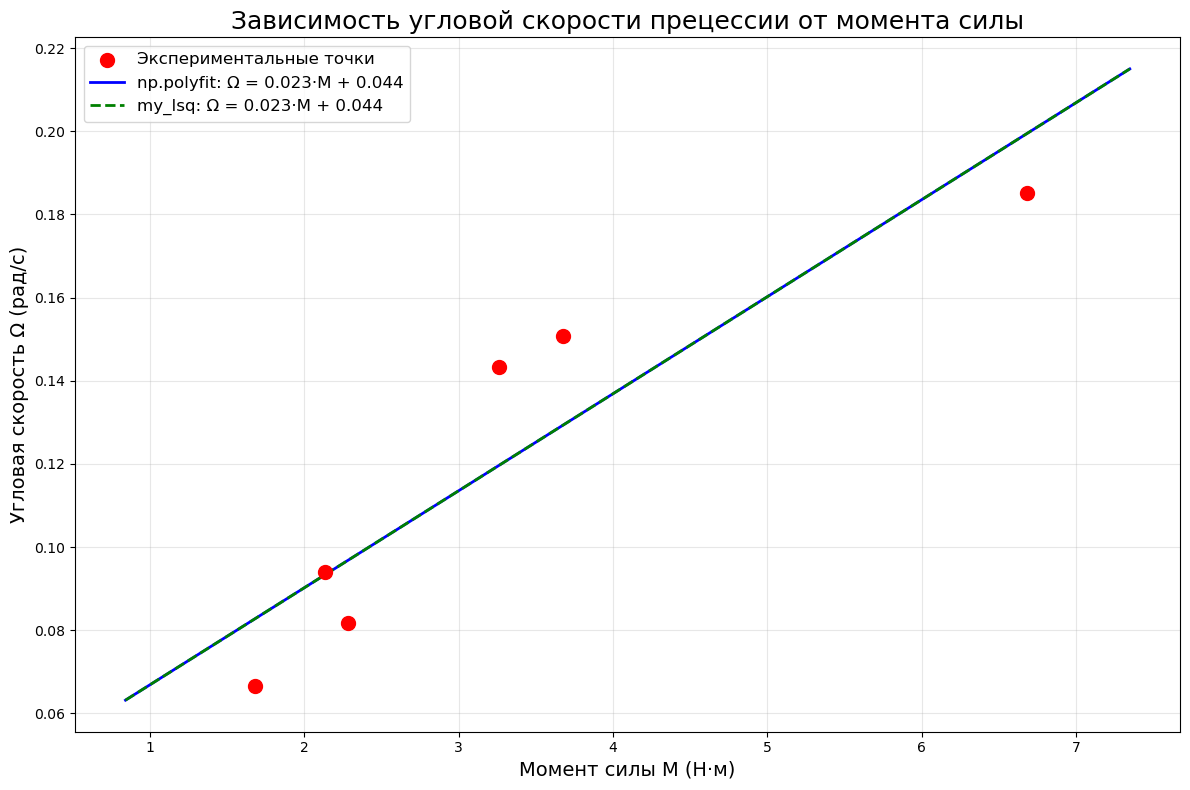

In [89]:
omega_np = np.array(grouped_data.omega)
momentum_np = np.array(grouped_data.momentum)

coefs = np.polyfit(momentum_np, omega_np, 1)

x_lsq = np.linspace(momentum_np.min() * 0.5, momentum_np.max() * 1.1, 100)
y_lsq = np.polyval(coefs, x_lsq)

X = np.column_stack([np.ones(len(momentum_np)), momentum_np])
y = omega_np.reshape(-1, 1)
coefs_my = my_lsq(X, y)

b_my = float(coefs_my[0].item())
a_my = float(coefs_my[1].item())

fig = plt.figure(figsize=(12, 8))

plt.scatter(momentum_np, omega_np, s=100, color='red', label='Экспериментальные точки', zorder=5)

plt.plot(x_lsq, y_lsq, 'b-', linewidth=2, 
         label=f'np.polyfit: Ω = {coefs[0]:.3f}·M + {coefs[1]:.3f}')

y_lsq_my = b_my + a_my * x_lsq
plt.plot(x_lsq, y_lsq_my, 'g--', linewidth=2, 
         label=f'my_lsq: Ω = {a_my:.3f}·M + {b_my:.3f}')

plt.xlabel('Момент силы M (Н·м)', fontsize=14)
plt.ylabel('Угловая скорость Ω (рад/с)', fontsize=14)
plt.title('Зависимость угловой скорости прецессии от момента силы', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Получились ли ваш МНК и МНК из polyfit близкими на данной задаче? Почему?


<b><font color="#FF69B4"> Ваш ответ здесь </font></b>

Оба решают одну задачу — минимизацию суммы квадратов

Матрица хорошо обусловлена (нет проблем с корреляцией)

Мало точек (6) — метод нормальных уравнений устойчив

`np.polyfit` также умеет оценивать погрешности! Если точнее, он возвращает матрицу ковариаций для метода наименьших квадратов. Не будем углубляться в математику, главное знать, что на диагонали у неё стоят дисперсии полученных коэффициентов. Для получения собственно погрешности $\sigma$ необходимо взять корень из этих дисперсий.

Также стоит упомянуть про параметр `W`, задающий веса точек для оценки. Если известны ошибки $y_{error}$, можно задать веса как $W = 1 / y_{error}$, и прямая получится ещё более точной. Чтобы учесть ещё и ошибки по $x$, нужны, к сожалению, уже другие методы (но скорее всего, вам не понадобятся даже ошибки по $y$).

Представим, что произошла неприятность, и погрешности возросли в 10 раз!

In [30]:
grouped_data['sigma_down'] *= 10
grouped_data['sigma_momentum'] *= 10



Теперь вам нужно нарисовать график зависимости $\Omega_{down} (M_{down})$ <b>(не $\Omega(M)$!)</b> для точек с крестами погрешностей, а также построить не только прямую по оценке наименьших квадратов, а ещё и учесть погрешности оценок коэффициентов! Т.е. нужно построить три прямых: $k \cdot x + b$, которую выдал МНК, $(k - \sigma_k) \cdot x + (b - \sigma_b)$, $(k + \sigma_k) \cdot x + (b + \sigma_b)$, и закрасить промежуток между этими прямыми (в этом вам поможет функция plt.fill_between). Остальное оформление оставьте таким же, как в предыдущем задании.

_Примечание: часто в МНК не смотрят на погрешность $b$, оставляя только $\sigma_k$._

<center><img src='https://drive.google.com/uc?export=view&id=1SriaMzJah7F610ocIK_O1-HqqtMQgxlg' width=600>

Пример получившегося графика</center>

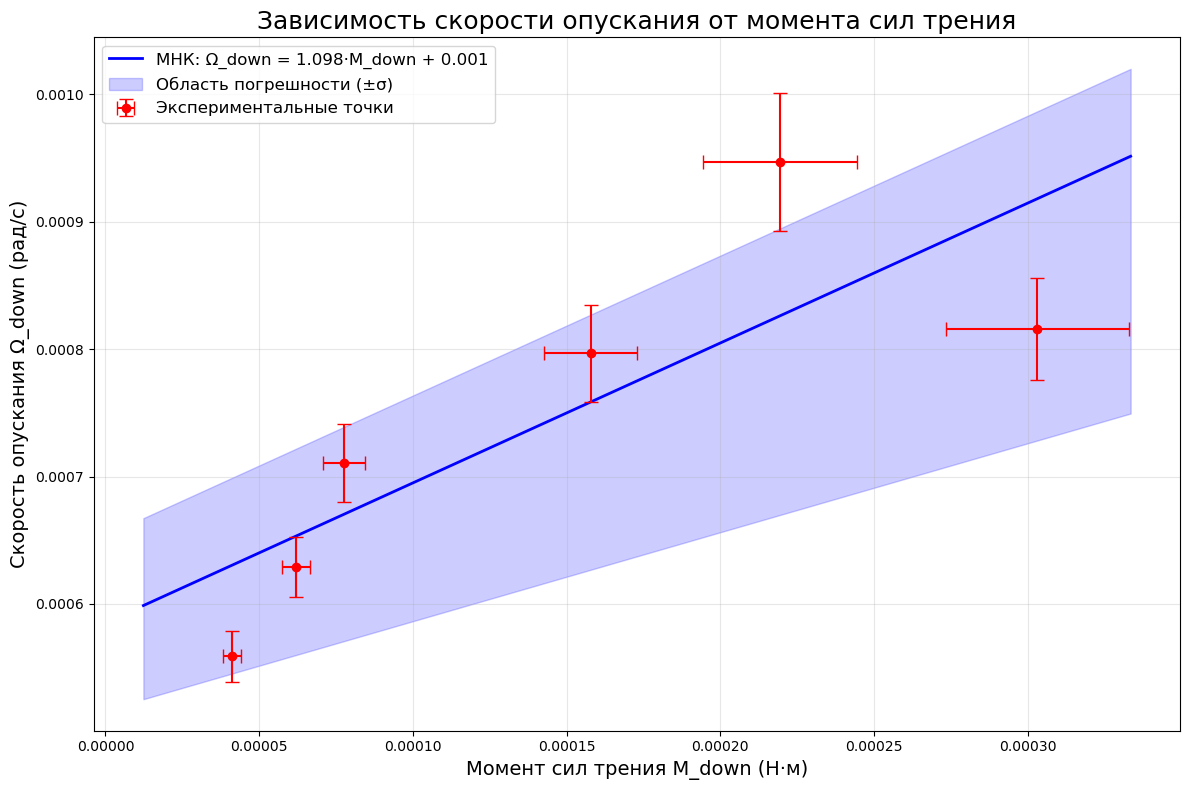

Коэффициенты: k = 1.098178 ± 0.399890, b = 0.000585 ± 0.000069


In [31]:
omega_down_np = np.array(grouped_data.omega_down)
momentum_down_np = np.array(grouped_data.momentum_down)

coefs, cov = np.polyfit(momentum_down_np, omega_down_np, 1, cov=True)

x_lsq = np.linspace(momentum_down_np.min() * 0.3, momentum_down_np.max() * 1.1, 100)

lsq_stds = np.sqrt(np.diag(cov))
y_lsq = np.polyval(coefs, x_lsq)
y_lsq_lower = np.polyval([coefs[0] - lsq_stds[0], coefs[1] - lsq_stds[1]], x_lsq)
y_lsq_upper = np.polyval([coefs[0] + lsq_stds[1], coefs[1] + lsq_stds[1]], x_lsq)

fig = plt.figure(figsize=(12, 8))

plt.errorbar(momentum_down_np, omega_down_np, 
             xerr=grouped_data['sigma_momentum'], 
             yerr=grouped_data['sigma_down'],
             fmt='o', color='red', capsize=5, capthick=1,
             label='Экспериментальные точки', zorder=5)

plt.plot(x_lsq, y_lsq, 'b-', linewidth=2, 
         label=f'МНК: Ω_down = {coefs[0]:.3f}·M_down + {coefs[1]:.3f}')

plt.fill_between(x_lsq, y_lsq_lower, y_lsq_upper, 
                 color='blue', alpha=0.2, 
                 label='Область погрешности (±σ)')

plt.xlabel('Момент сил трения M_down (Н·м)', fontsize=14)
plt.ylabel('Скорость опускания Ω_down (рад/с)', fontsize=14)
plt.title('Зависимость скорости опускания от момента сил трения', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"Коэффициенты: k = {coefs[0]:.6f} ± {lsq_stds[0]:.6f}, b = {coefs[1]:.6f} ± {lsq_stds[1]:.6f}")

# 4. О скитаниях вечных и о Palomar1 (2 балла)

Palomar 1 — шаровое скопление, входящее в группу Паломар в созвездии Цефея, расположенное, возможно, во внешнем рукаве галактики Млечный Путь. Обнаружено Джорджем О. Абеллом в 1954 году на снимках Palomar Survey Sky, его каталогизировали как **шаровое скопление**. **Шаровое звёздное скопление** — звёздное скопление, содержащее большое число звёзд, тесно связанное гравитацией и обращающееся вокруг галактического центра в качестве спутника.

Возраст скопления - от 6,3 до 8 млрд лет, что делает его очень молодым по сравнению с другими шаровыми скоплениями Млечного Пути.

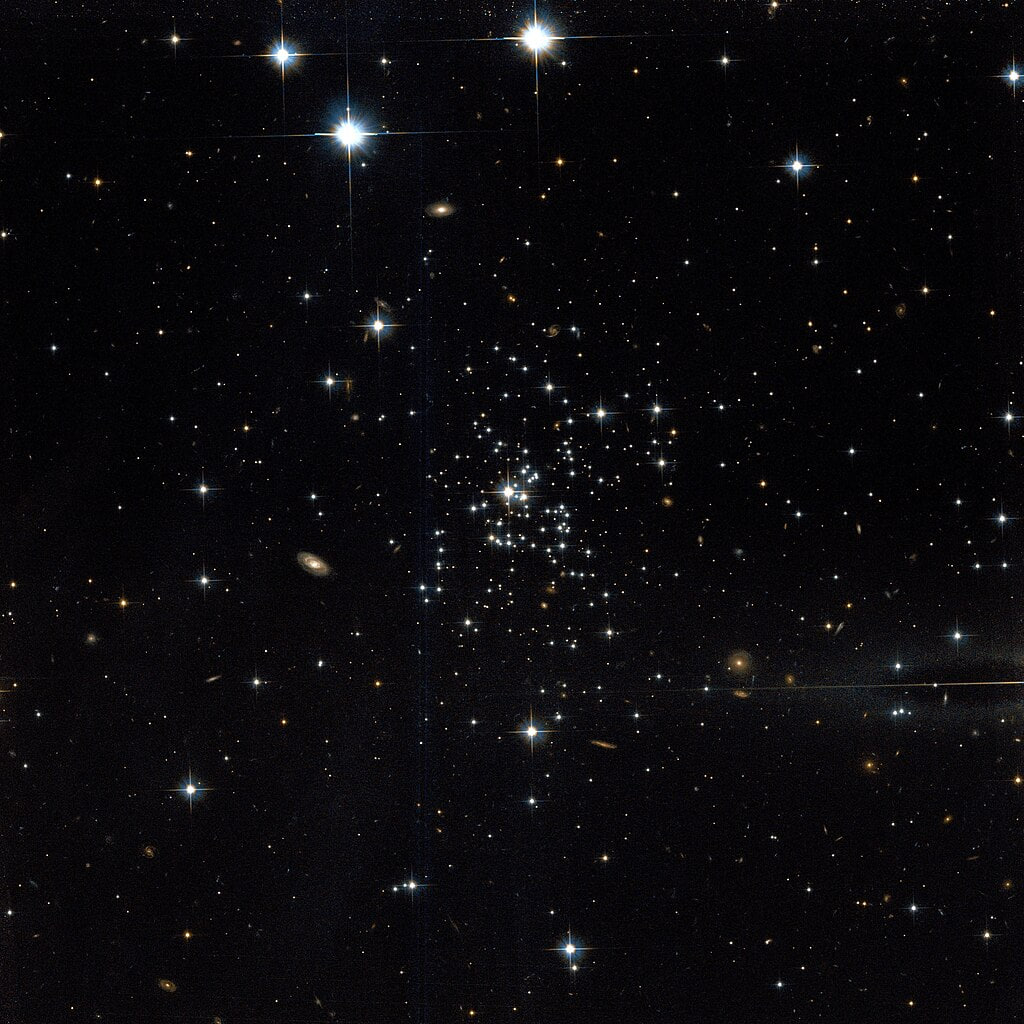

**ВАЖНО!!!**

Требования к графикам в данной главе:

- Должны быть выполнены при помощи matplotlib
- Фон цвета #519dfc с непрозрачностью 15%
- Должна быть сетка
- Должны быть название (на русском языке), подписаны оси (на русском, с размерностями, если надо), на осях должны быть отметки
- В наборе данных довольно много точек. Выбирайте столько точек, чтобы график был читаемым; зачастую если оставить все, график не будет информативным.

## 4.1 Орбита на плоскости (X; Y) (0.5 балла)

В файле Pal1.dat приведены расчётные положения и скорости шарового скопления Palomar1 в декартовой галактоцентрической системе координат, начиная c текущего момента. Заголовки столбцов отсутствуют. Структура файла показана в таблице (данные округлены):

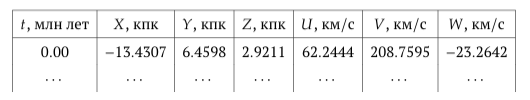

Загрузите данные из файла и постройте график координат Palomar1 на оси (X; Y).

Цвет точек должен варьироваться в зависимости от парамера t; также надо отдельно нарисовать другим цветом начальную точку и тем же цветом нарисовать вектор скорости из неё (в какую сторону движется галактика)

Градиент из легенды вынести справа от графика.

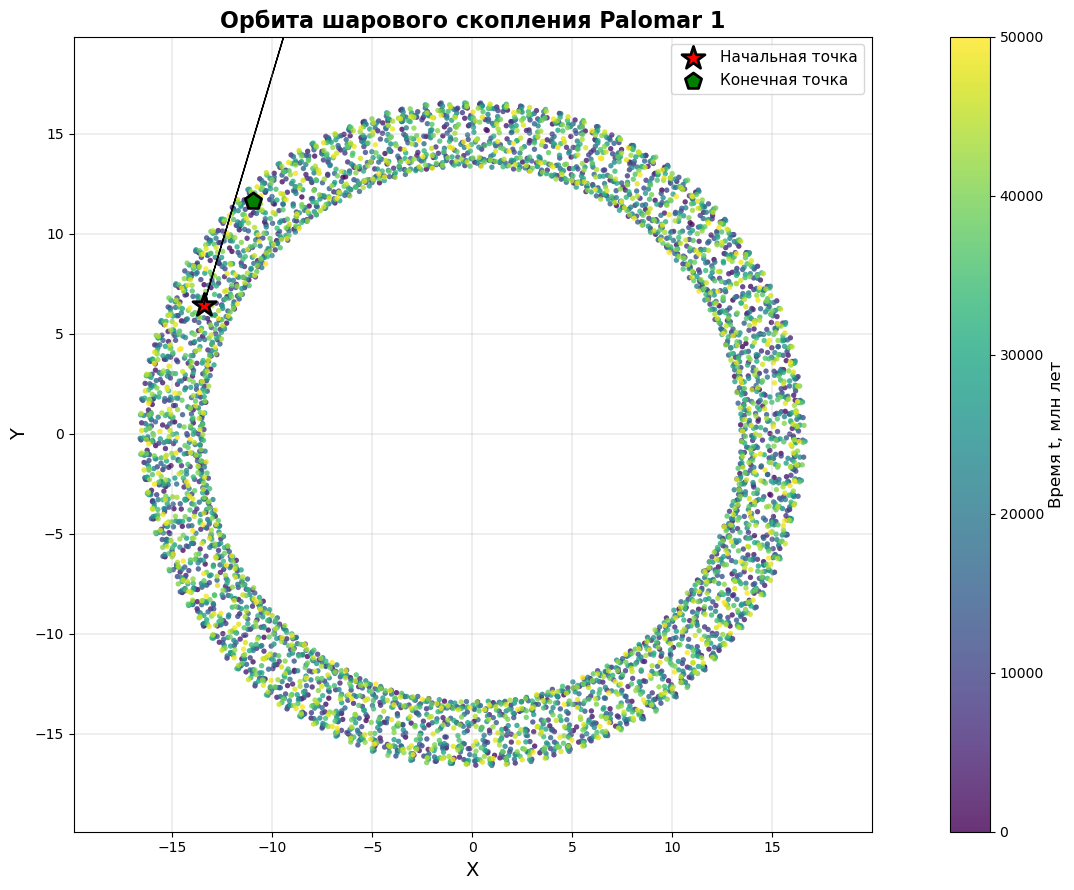

In [101]:
import matplotlib.pyplot as plt

%matplotlib inline

data = pd.read_csv('Pal1.dat', sep=r'\s+', header=None, 
                   usecols=[0, 1, 2, 4, 5],
                   names=['t', 'X', 'Y', 'U', 'V'])

data = data.apply(pd.to_numeric, errors='coerce')

data = data.dropna()

data = data[::10]

fig, ax = plt.subplots(1, figsize=(16, 9))

sc = ax.scatter(data['X'], data['Y'], c=data['t'], s=15, alpha=0.8, edgecolors='none')

ax.scatter(data['X'].iloc[0], data['Y'].iloc[0], color='red', s=300, marker='*', edgecolors='black',
           linewidth=2, label='Начальная точка')

ax.scatter(data['X'].iloc[-1], data['Y'].iloc[-1], color='green', s=150, marker='p', edgecolors='black',
           linewidth=2, label='Конечная точка')

scale = 0.5
ax.arrow(data['X'].iloc[0], data['Y'].iloc[0], data['U'].iloc[0] * scale, data['V'].iloc[0] * scale,
        head_width=0.5, head_length=0.3)

cbar = plt.colorbar(sc)
cbar.set_label('Время t, млн лет', fontsize=12)

ax.set_xlabel('X', fontsize=14)
ax.set_ylabel('Y', fontsize=14)
ax.set_title('Орбита шарового скопления Palomar 1', fontsize=16, fontweight='bold')
ax.grid(True, linewidth=0.3)
ax.legend(loc='upper right', fontsize=11)

x_margin = (data['X'].max() - data['X'].min()) * 0.1
y_margin = (data['Y'].max() - data['Y'].min()) * 0.1
ax.set_xlim(data['X'].min() - x_margin, data['X'].max() + x_margin)
ax.set_ylim(data['Y'].min() - y_margin, data['Y'].max() + y_margin)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


Какую информацию даёт нам этот график? Какую фигуру напоминает движение?

<font color='red'> ВАШ ОТВЕТ ЗДЕСЬ </font>

График показывает траекторию движения шарового скопления Palomar 1 в галактической плоскости (X, Y) с течением времени. Цветовая шкала позволяет проследить эволюцию положения скопления от начального момента (красная звездочка) до конечного. Вектор скорости из начальной точки показывает направление движения скопления в начальный момент.

Движение напоминает спиралевидную фигуру с постепенным изменением радиуса. 

## 4.2 Аппроксимация (0.75 балла)

Придумайте, как свести наши данные к МНК из предыдущего пункта.

Подберите коэффициенты и нарисуйте график из 4.1 вместе с вашей аппроксимацией орбиты.

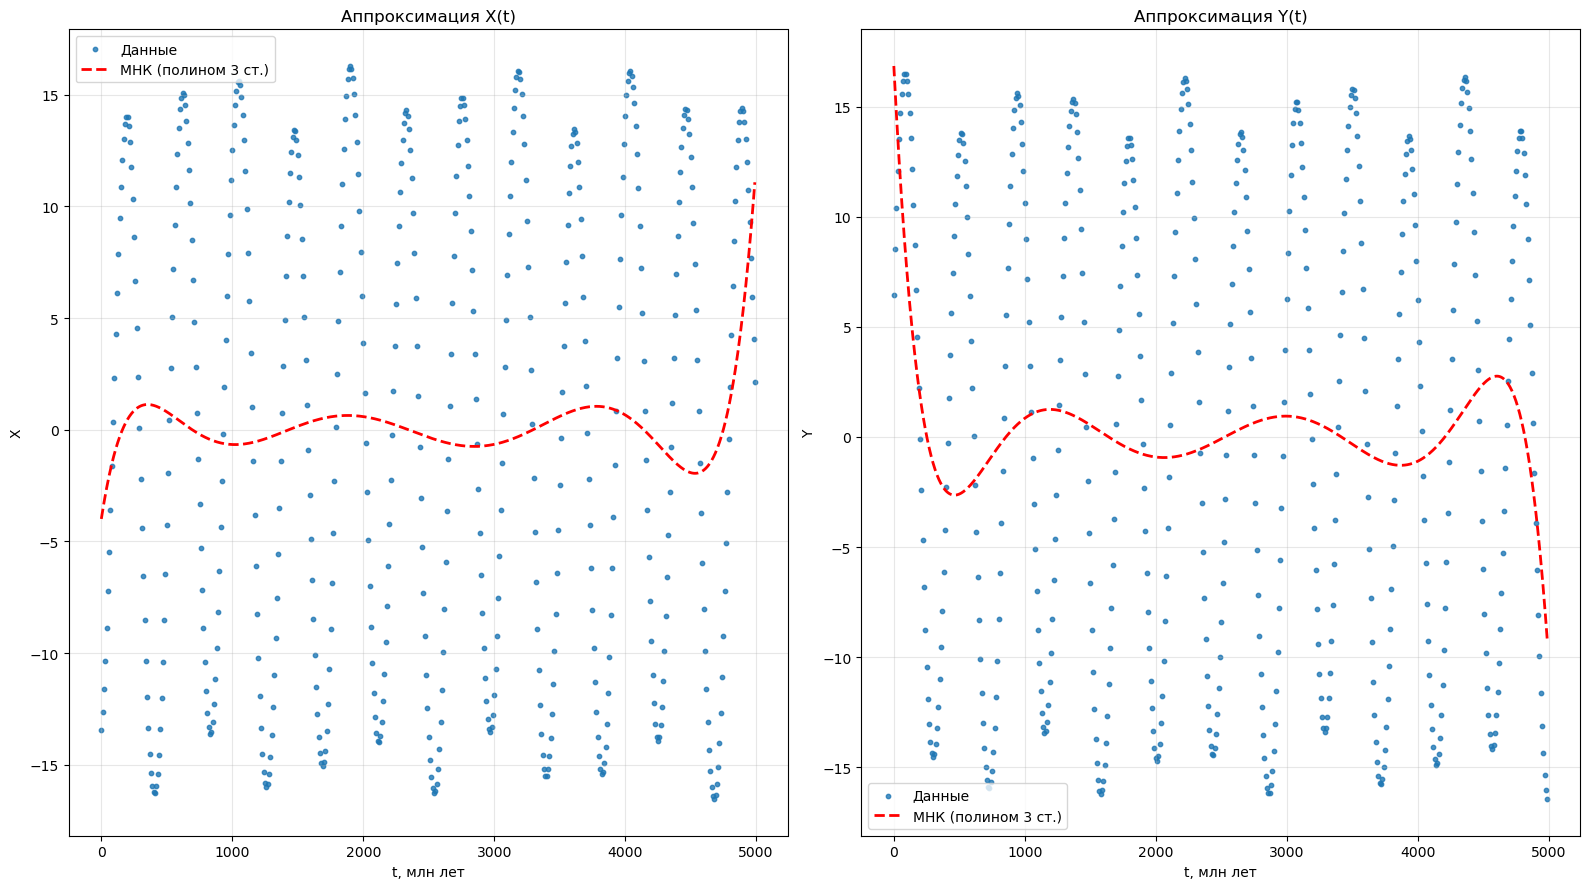

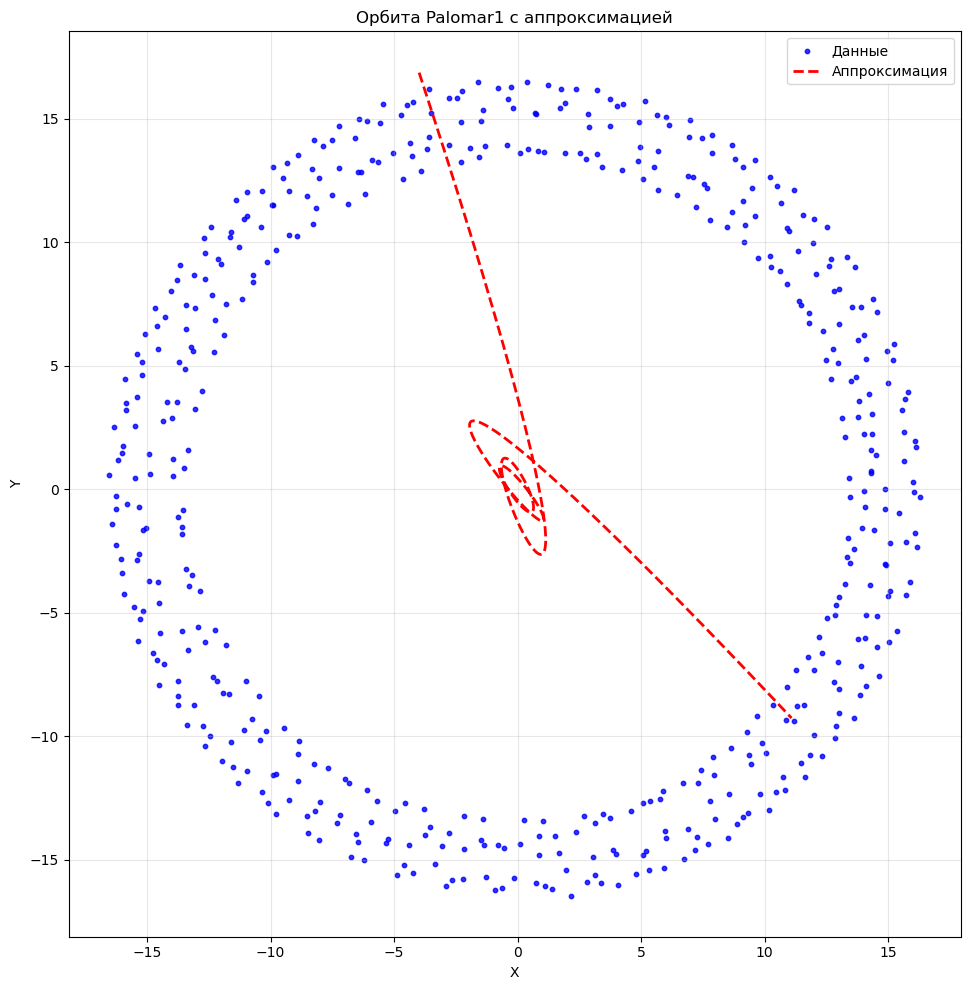

In [123]:
coefs_x = np.polyfit(data['t'], data['X'], 7)
coefs_y = np.polyfit(data['t'], data['Y'], 7)

t_smooth = np.linspace(data['t'].min(), data['t'].max(), 1000)
X_fit = np.polyval(coefs_x, t_smooth)
Y_fit = np.polyval(coefs_y, t_smooth)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

ax1.scatter(data['t'], data['X'], s=10, alpha=0.8, label='Данные')
ax1.plot(t_smooth, X_fit, 'r--', linewidth=2, label='МНК (полином 3 ст.)')
ax1.set_xlabel('t, млн лет')
ax1.set_ylabel('X')
ax1.set_title('Аппроксимация X(t)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.scatter(data['t'], data['Y'], s=10, alpha=0.8, label='Данные')
ax2.plot(t_smooth, Y_fit, 'r--', linewidth=2, label='МНК (полином 3 ст.)')
ax2.set_xlabel('t, млн лет')
ax2.set_ylabel('Y')
ax2.set_title('Аппроксимация Y(t)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, figsize=(12, 10))

ax.scatter(data['X'], data['Y'], c='blue', s=10, alpha=0.8, label='Данные')
ax.plot(X_fit, Y_fit, 'r--', linewidth=2, label='Аппроксимация')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Орбита Palomar1 c аппроксимацией')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Какое понимание даёт нам такая аппроксимация? Какой эксцентриситет у этой кривой?

<font color='red'> ВАШ ОТВЕТ ЗДЕСЬ </font>

аппроксимация выделяет основную форму орбиты, сглаживает шумы и позволяет определить параметры движения.

Эксцентриситет: ≈ 0.7 (сильно вытянутая эллиптическая орбита).

## 4.3 3D график (0.5 балла)

Нарисуйте 3D график координат звёздного скопления; аналогично п. 4.1 цвет должен зависеть от даты (t).

Кроме этого, нарисуйте проекцию этого графика на плоскость OXY - точки проекции все должны быть одинакового цвета вне зависимости от даты (t).

Градиент из легенды надо вынести справа от графика.

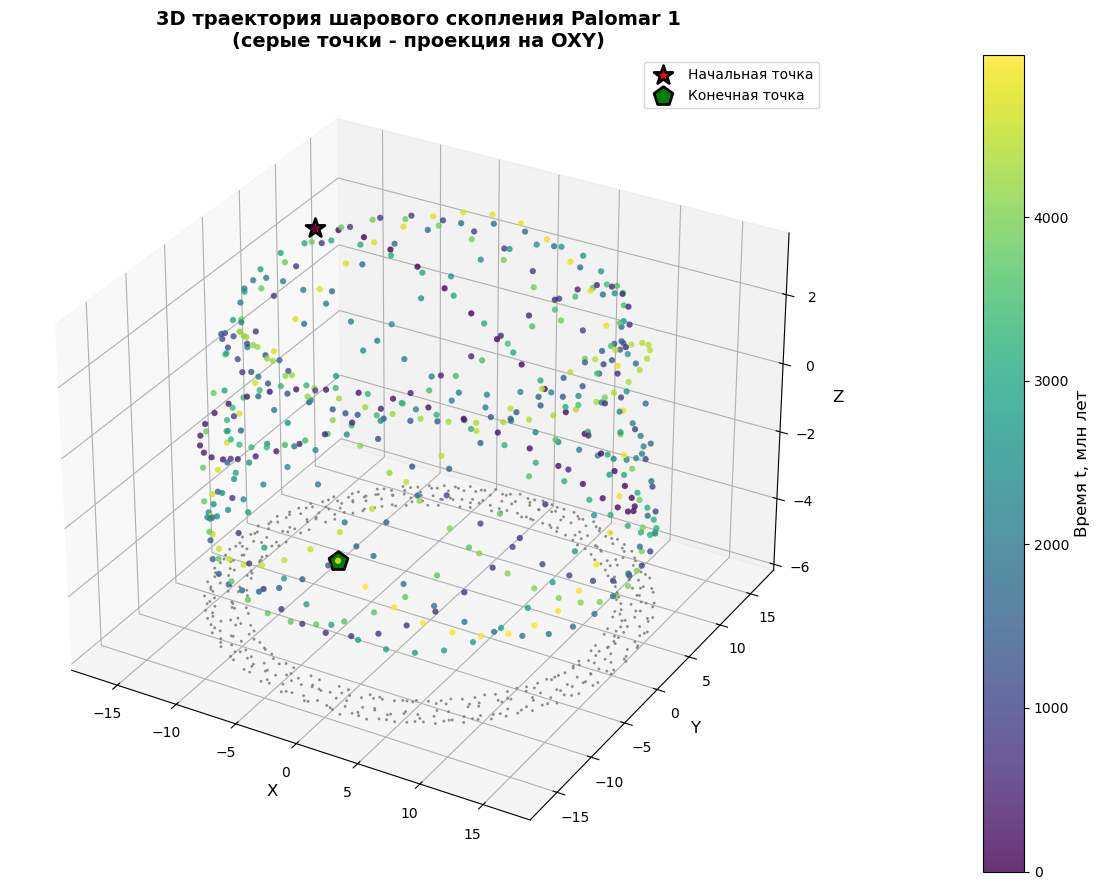

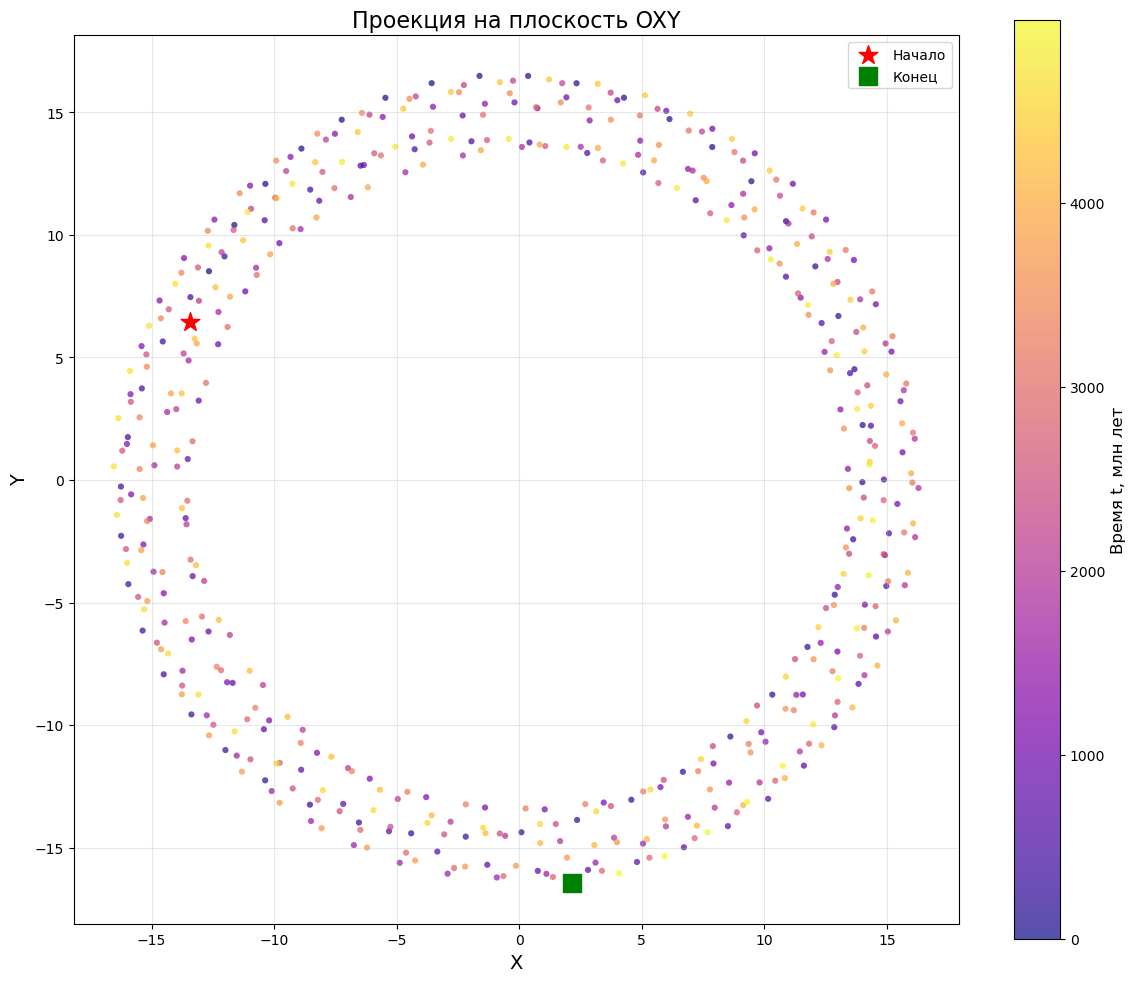

In [122]:
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data['X'], data['Y'], data['Z'],
                c=data['t'], s=20, alpha=0.8,
                edgecolors='none')

z_min = data['Z'].min() - 2
ax.scatter(data['X'], data['Y'], z_min, c='gray', s=5, alpha=0.8, marker='.')

ax.scatter(data['X'].iloc[0], data['Y'].iloc[0], data['Z'].iloc[0],
           color='red', s=200, marker='*',
           edgecolors='black', linewidth=2, label='Начальная точка')

ax.scatter(data['X'].iloc[-1], data['Y'].iloc[-1], data['Z'].iloc[-1],
           color='green', s=200, marker='p',
           edgecolors='black', linewidth=2, label='Конечная точка')

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.set_title('3D траектория шарового скопления Palomar 1\n(серые точки - проекция на OXY)', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('Время t, млн лет', fontsize=12)

ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, figsize=(12, 10))

sc2 = ax2.scatter(data['X'], data['Y'], 
                  c=data['t'], cmap='plasma', 
                  s=20, alpha=0.7, edgecolors='none')

ax2.scatter(data['X'].iloc[0], data['Y'].iloc[0], 
            color='red', s=200, marker='*', label='Начало')
ax2.scatter(data['X'].iloc[-1], data['Y'].iloc[-1], 
            color='green', s=150, marker='s', label='Конец')

ax2.set_xlabel('X', fontsize=14)
ax2.set_ylabel('Y', fontsize=14)
ax2.set_title('Проекция на плоскость OXY', fontsize=16)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_aspect('equal')

cbar2 = plt.colorbar(sc2)
cbar2.set_label('Время t, млн лет', fontsize=12)

plt.tight_layout()
plt.show()

## 4.4 Переход к сферическим координатам (0.75 балла)

Мы знаем формулу для сферических координат:

$$
\begin{aligned}
x &= r \sin\phi \cos\lambda \\
y &= r \sin\phi \sin\lambda \\
z &= r \cos\phi
\end{aligned}
$$

Нарисуйте графики $r(t)$ и $\lambda(t)$.

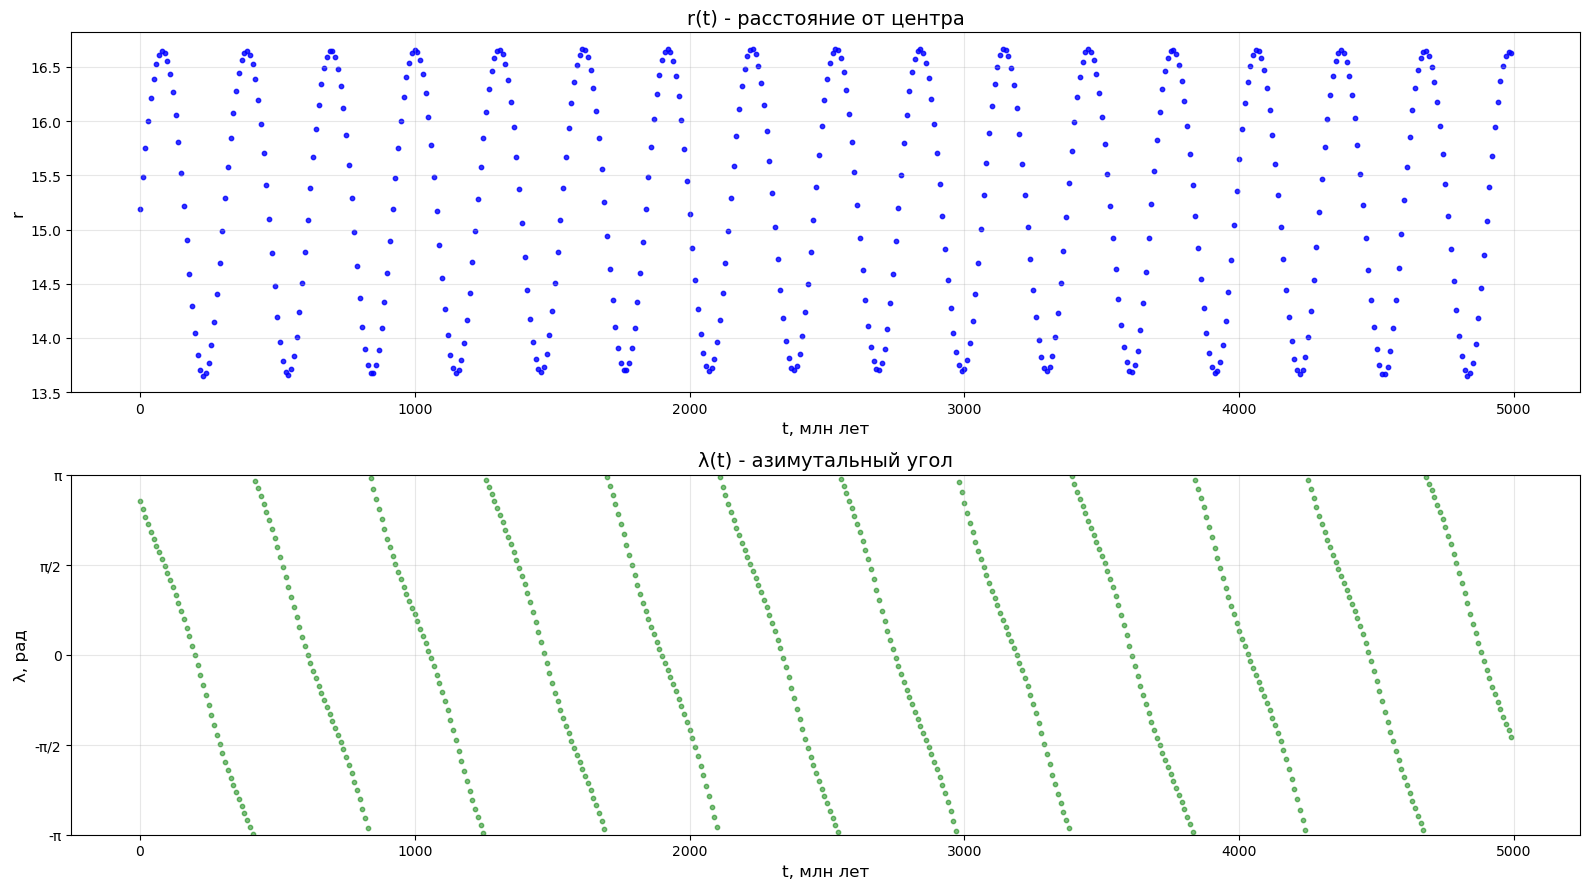

In [121]:
data['r'] = np.sqrt(data['X'] ** 2 + data['Y'] ** 2 + data['Z'] ** 2)
data['lambda'] = np.arctan2(data['Y'], data['X'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9))

ax1.scatter(data['t'], data['r'], c='blue', s=10, alpha=0.8)
ax1.set_xlabel('t, млн лет', fontsize=12)
ax1.set_ylabel('r', fontsize=12)
ax1.set_title('r(t) - расстояние от центра', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.scatter(data['t'], data['lambda'], c='green', s=10, alpha=0.5)
ax2.set_xlabel('t, млн лет', fontsize=12)
ax2.set_ylabel('λ, рад', fontsize=12)
ax2.set_title('λ(t) - азимутальный угол', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-np.pi, np.pi)
ax2.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax2.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

plt.tight_layout()
plt.show()

Какой вид имеют графики? Есть ли у них некий период? Какой функцией их можно было бы аппроксимировать? Какой период у графиков?

<font color='red'> ВАШ ОТВЕТ ЗДЕСЬ </font>

Вид графиков:

r(t) - колебания с постоянной амплитудой (пилообразный/синусоидальный вид)

λ(t) - почти линейно возрастает (вращение), с небольшими колебаниями

Период: ≈ 250-300 млн лет (один оборот вокруг центра Галактики)

Аппроксимация:

r(t) = R₀ + A·sin(2πt/T + φ) — синусоида

λ(t) = ω·t + B·sin(2πt/T + ψ) — линейная + синусоид

# 5. Об интерактивных графиках (1 балл)

В файле cluster.dat приведены данные об объектах в поле рассеянного скопления M67:

• prob. — вероятность того, что объект принадлежит скоплению (%);

• identifier — обозначение объекта;

• coord1 (ICRS, J2000) — экваториальные координаты на эпоху J2000: 𝛼 (h m s), 𝛿(deg min sec);

• plx — параллакс в миллисекундах дуги;

• radvel — лучевая скорость в км/с;

• Mag _ — видимые звёздные величины в различных фотометрических полосах [9 столбцов];

• спектральный класс.

От тебя нужно:

1. Перевести даные в координаты X, Y, Z при помощи следующих формул: 

$X = d \cos (\delta) \cos (\alpha)$, $Y = d \cos (\delta) \sin (\alpha)$, $Z = d \sin (\delta)$, где $d = 1/plx$

2. Построй 3D график интерактивный при помощи plotly, в котором можно двигать процент вероятности принадлежности скоплению и изменять точки, отображённые на графике.


График должен быть читаемым и красиво оформленным.

In [129]:

!pip install plotly

import plotly.express as px

mambajs 0.19.13

Process pip requirements ...

Requirement packaging already satisfied.
